# **Assignment 2**

This notebook contains the code for assignment 2, tasks 0-8

**AI STATEMENT**

AI has been used for this assignment to help with writing code and to assess and correct errors in the code.

AI used for the assignment: GPT-5.3 (ChatGPT)

## **Task 0: Course project dataset exploration**

### a) Dataset and link

Name: Premier League data

The data was found on kaggle.com and the link to the dataset is found below:

https://www.kaggle.com/datasets/zaeemnalla/premier-league/data


### b) Data description

The data contains match data over 12 seasons from the English Premier League from the 2006/2007 season to the 2017/2018 season.

The dataset consists of a total of 4560 rows where each row represents a single match.

The dataset contains the following variables:

i.    home_team

ii.   away_team

iii.  home_goals

iv.   away_goals

v.    result

vi.   season

The dataset will be used to analyze patterns in match outcomes. This includes examining goal distributions, comparing home and away performance, and identifying potential trends across different seasons.

### c) Data analysis

In [90]:
from google.colab import files

uploaded = files.upload()



KeyboardInterrupt: 

In [ ]:
!ls

In [91]:
# Loading the data

import pandas as pd

df = pd.read_excel("pl_results.xlsm")
df.head()


,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007


In [92]:
# checking the structure of the dataset

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   4560 non-null   object 
 1   away_team   4560 non-null   object 
 2   home_goals  4560 non-null   float64
 3   away_goals  4560 non-null   float64
 4   result      4560 non-null   object 
 5   season      4560 non-null   object 
dtypes: float64(2), object(4)
memory usage: 213.9+ KB


In [93]:
# Summary statistics of numerical variables home_goals and away_goals using describe()

df.describe()


,home_goals,away_goals
count,4560.000000,4560.000000
mean,1.543202,1.144298
std,1.315163,1.139824
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,7.000000


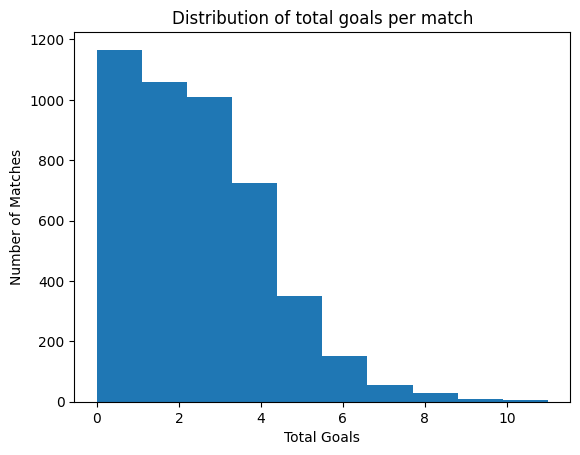

In [94]:
# Hisorgram showing the distribution of goals per match

import matplotlib.pyplot as plt

# Create total goals per match
df["total_goals"] = df["home_goals"] + df["away_goals"]

plt.figure()
plt.hist(df["total_goals"], bins=10)

plt.title("Distribution of total goals per match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.show()



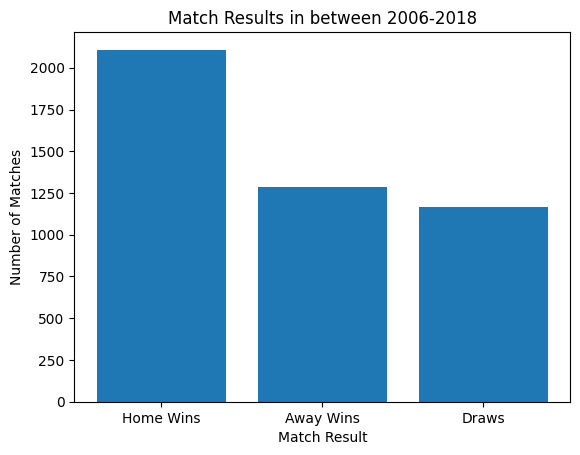

In [95]:
import matplotlib.pyplot as plt

home_wins = (df["result"] == "H").sum()
away_wins = (df["result"] == "A").sum()
draws = (df["result"] == "D").sum()

result_counts = [home_wins, away_wins, draws]
result_labels = ["Home Wins", "Away Wins", "Draws"]

plt.figure()
plt.bar(result_labels, result_counts)
plt.title("Match Results in between 2006-2018")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")
plt.show()


## **Task 1: Setting up an API key and .env file**

In [96]:
# Creating a new .env file:

# The API key is entered securly using hidden input and written to a .env file.


from getpass import getpass

api_key_input = getpass("Enter your API key: ")

with open (".env", "w") as f:
  f.write(f"API_KEY={api_key_input}\n")

print(".env file created")


Enter your API key: ··········
.env file created


In [97]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_KEY")

print(api_key[:5] + "...")

1e5ed...


In [98]:
%%writefile .gitignore
.env

Overwriting .gitignore


## **Task 2: Retrieving data from MarketStack**

### a) Retrieve End-of-Day (eod) data for these five stocks for March 2026.

In [99]:
import requests

symbols = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

all_data = []

for symbol in symbols:
    params = {
        "access_key": api_key,
        "symbols": symbol,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 200
    }

    response = requests.get("http://api.marketstack.com/v1/eod", params=params)
    data = response.json()

    all_data.extend(data["data"])

### b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

In [100]:
import pandas as pd

# Extract data part from JSON
df_api = pd.DataFrame(all_data)

#Display the first 5 rows
df_api.head()


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


### c) Summary statistics

In [101]:
# Convert date column to datetime
df_api["date"] = pd.to_datetime(df_api["date"])

# Sort values
df_api = df_api.sort_values(by=["symbol", "date"])


In [ ]:
summary_stats = df_api.groupby("symbol")["close"].describe()
summary_stats

In [102]:
# Calculating the return percentage for each stock

returns = {}

for symbol, group in df_api.groupby("symbol"):
    first_price = group.iloc[0]["close"]
    last_price = group.iloc[-1]["close"]

    return_pct = ((last_price - first_price) / first_price) * 100
    returns[symbol] = return_pct

# Converting to DataFrame

returns_df = pd.DataFrame(list(returns.items()), columns=["stock", "Return (%)"])

returns_df

,stock,Return (%)
0,AAPL,-4.128891
1,AMZN,-0.057584
2,GOOG,-6.365061
3,META,-12.459453
4,NFLX,-0.968174


In [103]:
# Identify best and worst performing stocks
best_stock = returns_df.loc[returns_df["Return (%)"].idxmax()]
worst_stock = returns_df.loc[returns_df["Return (%)"].idxmin()]

print("Best performing stock:")
print(best_stock)

print("\nWorst performing stock:")
print(worst_stock)

Best performing stock:
stock             AMZN
Return (%)   -0.057584
Name: 1, dtype: object

Worst performing stock:
stock              META
Return (%)   -12.459453
Name: 3, dtype: object


## **Task 3: Visualizing stock data**


In [104]:
# Importing libraries

import seaborn as sns
import matplotlib.pyplot as plt

### a) Line chart showing the closing price of each stock over time during March 2026

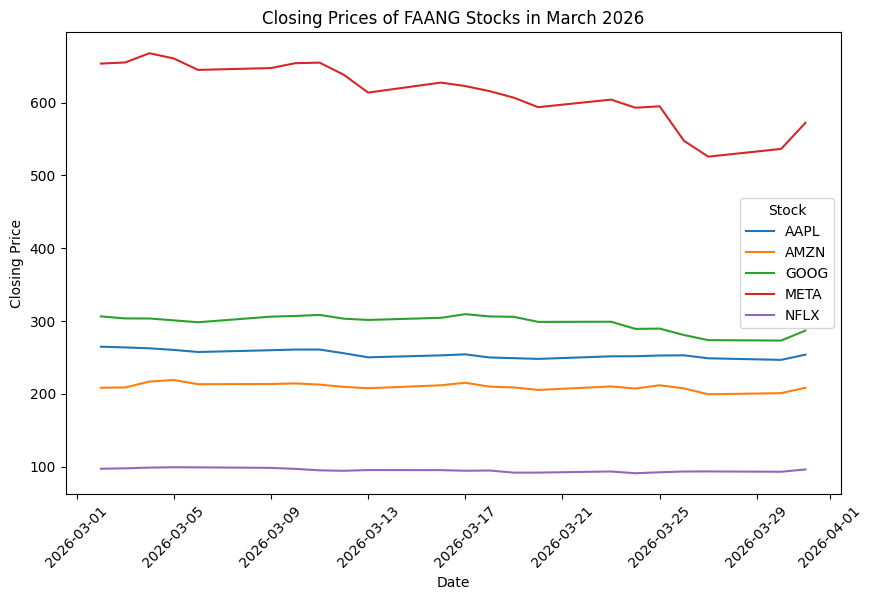

In [105]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_api, x="date", y="close", hue="symbol")

plt.title("Closing Prices of FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Stock")
plt.xticks(rotation=45)
plt.show()

### b) Bar plot showing the overall return percentage for each stock in March 2026.

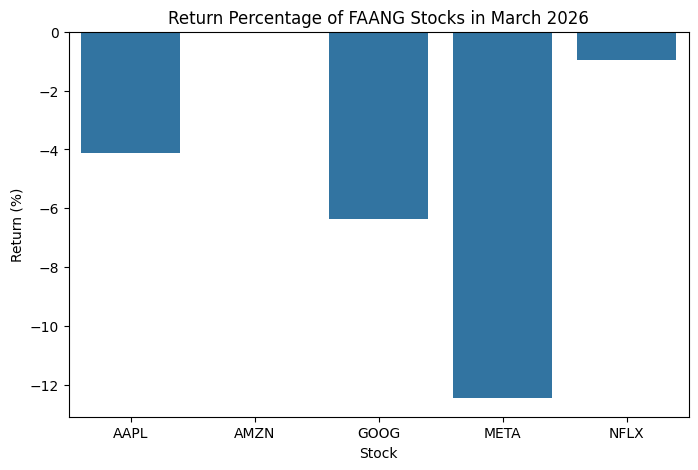

In [106]:
# Bar plot of return percentages for each stock
plt.figure(figsize=(8, 5))
sns.barplot(data=returns_df, x="stock", y="Return (%)")

plt.title("Return Percentage of FAANG Stocks in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.show()

### c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis)

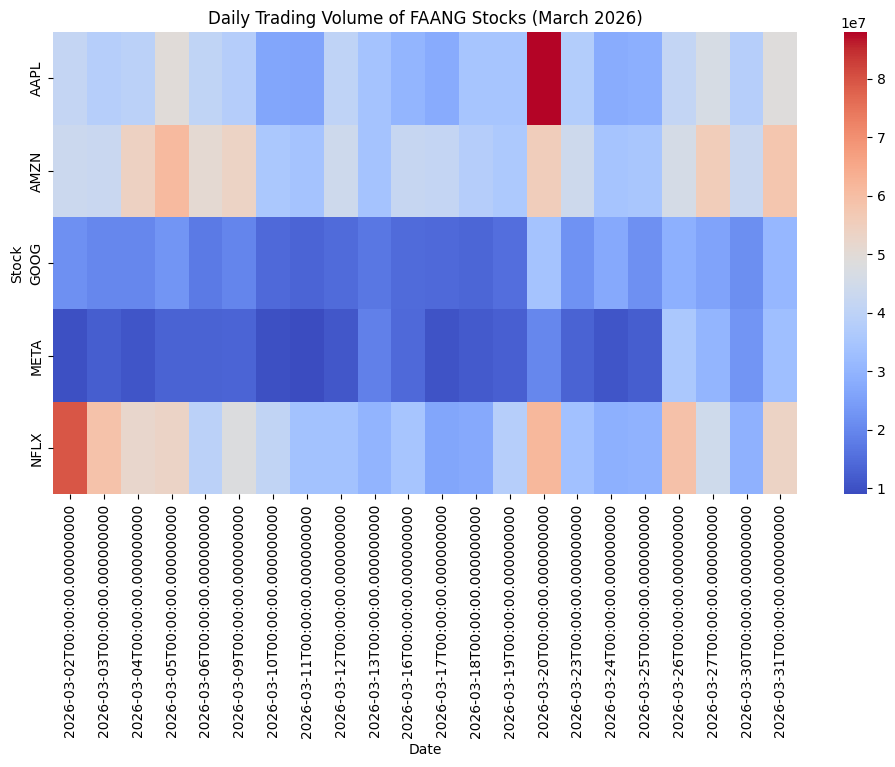

In [107]:
# Create pivot table for heatmap (volume by date and stock)
pivot_table = df_api.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="coolwarm")

plt.title("Daily Trading Volume of FAANG Stocks (March 2026)")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.show()

## **Task 4: Exporting and importing data**

a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.

In [108]:
import json
import os

# Create exports folder
os.makedirs("exports", exist_ok=True)

# Save JSON data
with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f)

print("JSON file saved.")

JSON file saved.


### b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

In [109]:
# Save DataFrame as CSV in exports folder
df_api.to_csv("exports/stockdata.csv", index=False)

print("CSV file saved.")

CSV file saved.


### c) Load back the exported data from both a) and b) and printing the first 5 rows.

In [110]:
import json
import pandas as pd

# Load JSON file
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)

df_json = pd.DataFrame(loaded_json)

# Load CSV file
df_csv = pd.read_csv("exports/stockdata.csv")

# Display first 5 rows of each
print("JSON DataFrame:")
display(df_json.head())

print("\nCSV DataFrame:")
display(df_csv.head())

JSON DataFrame:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000



CSV DataFrame:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02 00:00:00+00:00
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03 00:00:00+00:00
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04 00:00:00+00:00
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05 00:00:00+00:00
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06 00:00:00+00:00


## **Task 5: Querying the Northwind database**

### a) Connecting to the Nortwind database and listing the tables it consists

In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import sqlite3

# Connect to database
conn = sqlite3.connect("northwind.db")

# Create cursor
cursor = conn.cursor()

# Get all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

# Print table names
print("Tables in database:")
for table in tables:
    print(table[0])

### b) SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

In [ ]:
query = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""

df_products = pd.read_sql_query(query, conn)

df_products

### c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it.

In [ ]:
query = """
SELECT
    Customers.CompanyName,
    Orders.OrderID,
    Orders.OrderDate,
    Orders.ShipCountry,
    "Order Details".UnitPrice * "Order Details".Quantity AS LineTotal
FROM Orders
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
JOIN "Order Details" ON Orders.OrderID = "Order Details".OrderID
WHERE Orders.ShipCountry = 'Germany'
"""

df_germany = pd.read_sql_query(query, conn)

df_germany.head()

## **Task 6: Visualizing Northwind data**


### a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

In [ ]:
# Count number of orders per customer
orders_per_customer = df_germany.groupby("CompanyName")["OrderID"].nunique()

# Get top 10 customers
top_customers = orders_per_customer.sort_values(ascending=False).head(10)

# Convert to DataFrame for plotting
top_customers_df = top_customers.reset_index()
top_customers_df.columns = ["CompanyName", "OrderCount"]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers_df, x="OrderCount", y="CompanyName")

plt.title("Top 10 Customers by Number of Orders (Germany)")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.show()

### b) Density plot (KDE plot) of daily total sales for orders shipped to Germany.

In [ ]:
# Compute total sales per day
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum().reset_index()

# Plot KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)

plt.title("Density Plot of Daily Total Sales (Germany)")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")

plt.show()

### c) SQL query


In [ ]:
query = """
SELECT
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products ON "Order Details".ProductID = Products.ProductID
JOIN Categories ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName
"""

df_category = pd.read_sql_query(query, conn)

df_category.head()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_category, x="TotalRevenue", y="CategoryName")

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.show()

## **Task 7: Comparing Python to SQL**
  

### a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

In [ ]:
# Retrieve full Products table
query_products = "SELECT * FROM Products"
df_products_full = pd.read_sql_query(query_products, conn)

# Retrieve full Categories table
query_categories = "SELECT * FROM Categories"
df_categories_full = pd.read_sql_query(query_categories, conn)

# Display first 5 rows of each table
print("Products table:")
display(df_products_full.head())

print("\nCategories table:")
display(df_categories_full.head())

### b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

In [ ]:
# Inner join on CategoryID
df_joined = pd.merge(df_products_full, df_categories_full, on="CategoryID", how="inner")

# Display result
df_joined.head()

### c)

In [ ]:
import time

# --- SQL JOIN timing ---
start_sql = time.time()

query = """
SELECT
    Categories.CategoryName,
    SUM("Order Details".UnitPrice * "Order Details".Quantity) AS TotalRevenue
FROM "Order Details"
JOIN Products ON "Order Details".ProductID = Products.ProductID
JOIN Categories ON Products.CategoryID = Categories.CategoryID
GROUP BY Categories.CategoryName
"""

df_sql = pd.read_sql_query(query, conn)

end_sql = time.time()
sql_time = end_sql - start_sql


# --- pandas JOIN timing ---
start_pd = time.time()

# Load tables
df_order_details = pd.read_sql_query('SELECT * FROM "Order Details"', conn)
df_products = pd.read_sql_query("SELECT * FROM Products", conn)
df_categories = pd.read_sql_query("SELECT * FROM Categories", conn)

# Perform joins
df_pd = df_order_details.merge(df_products, on="ProductID")
df_pd = df_pd.merge(df_categories, on="CategoryID")

# Compute revenue per category
df_pd["LineTotal"] = df_pd["UnitPrice_x"] * df_pd["Quantity"]
df_pd_grouped = df_pd.groupby("CategoryName")["LineTotal"].sum().reset_index()

end_pd = time.time()
pd_time = end_pd - start_pd



print(f"SQL execution time: {sql_time:.6f} seconds")
print(f"Pandas execution time: {pd_time:.6f} seconds")

## **Task 8: Wide and long format**


In [ ]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})



### a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

In [ ]:
# Print original
print("Original wide data:")
display(wide_data)

# Convert to long format
wide_to_long = pd.melt(wide_data, id_vars="store", var_name="Quarter", value_name="Sales")

# Print converted
print("\nLong format:")
display(wide_to_long)

### b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

In [ ]:
# Create long dataset
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# Print original
print("Original long data:")
display(long_data)

# Convert to wide format
long_to_wide = long_data.pivot(index="month", columns="product", values="units_sold")

# Print converted
print("\nWide format:")
display(long_to_wide)

### c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [ ]:
# Convert wide_to_long back to original wide format
long_back_to_wide = wide_to_long.pivot(index="store", columns="Quarter", values="Sales").reset_index()

# Reorder columns to match the original wide_data
long_back_to_wide = long_back_to_wide[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]

# Convert long_to_wide back to original long format
wide_back_to_long = long_to_wide.reset_index().melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

# Print results
print("Original wide_data:")
display(wide_data)

print("\nConverted back to wide format:")
display(long_back_to_wide)

print("\nOriginal long_data:")
display(long_data)

print("\nConverted back to long format:")
display(wide_back_to_long)